<a href="https://colab.research.google.com/github/Sanvi2811/Machine_Learning_Project/blob/main/Machine_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Data preprocessing


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("tmdb_5000_movies.csv")


In [8]:
df.head()


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [10]:
df.isnull().sum()

,0
budget,0
genres,0
homepage,3091
id,0
keywords,0
original_language,0
original_title,0
overview,3
popularity,0
production_companies,0


In [11]:
print(df.columns)

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')


In [12]:
#Target Variable
df['success'] = df['revenue'] > df['budget']
df['success'] = df['success'].astype(int)

In [13]:
print(df[['budget', 'revenue', 'success']].head())

      budget     revenue  success
0  237000000  2787965087        1
1  300000000   961000000        1
2  245000000   880674609        1
3  250000000  1084939099        1
4  260000000   284139100        1


In [14]:
#Remove Invalid Data
df = df[df['budget'] > 0]
df = df[df['revenue'] > 0]

In [15]:
print(df.shape)

(3229, 21)


In [16]:
# Selecting the feature
features = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count']

X = df[features]
y = df['success']

In [17]:
# Handling missing values
X = X.fillna(X.mean())

In [18]:
print(X.isnull().sum())

budget          0
popularity      0
runtime         0
vote_average    0
vote_count      0
dtype: int64


In [19]:
# Splitting training and testing data


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
# Logistic Regression Model Implementation

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

class LogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred):
        m = len(y)

        loss = -(1/m) * np.sum(y*np.log(y_pred + 1e-15) + (1 - y)*np.log(1 - y_pred + 1e-15))
        return loss

    def fit(self, X, y):
        self.theta = np.zeros(X.shape[1])
        self.bias = 0

        for epoch in range(self.epochs):
            linear_model = np.dot(X, self.theta) + self.bias
            y_pred = self.sigmoid(linear_model)


            m = len(y)
            dtheta = (1/m) * np.dot(X.T, (y_pred - y))
            dbias = (1/m) * np.sum(y_pred - y)


            self.theta -= self.learning_rate * dtheta
            self.bias -= self.learning_rate * dbias


            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)

    def predict_prob(self, X):
        linear_model = np.dot(X, self.theta) + self.bias
        return self.sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        y_prob = self.predict_prob(X)
        return np.where(y_prob >= threshold, 1, 0)



In [24]:
model = LogisticRegression(learning_rate=0.01, epochs=1000)

In [25]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7755417956656346
Precision: 0.7801302931596091
Recall: 0.9795501022494888
F1 Score: 0.8685403445149592
Confusion Matrix:
 [[ 22 135]
 [ 10 479]]


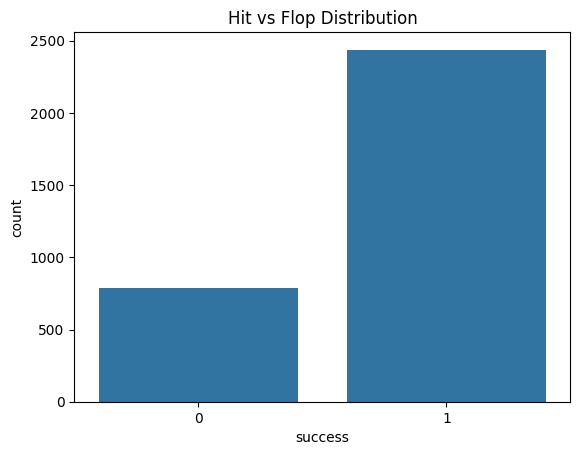

In [27]:
sns.countplot(x=y)
plt.title("Hit vs Flop Distribution")
plt.show()

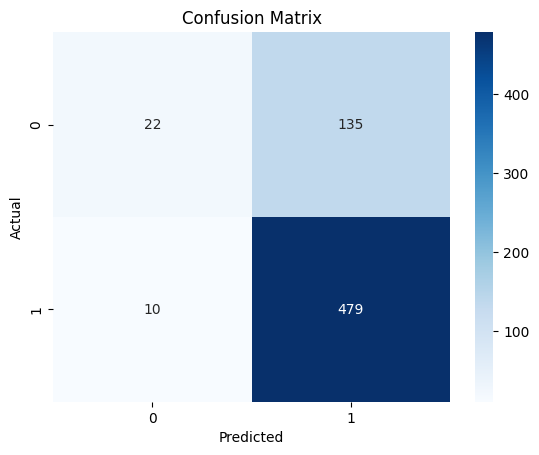

In [28]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

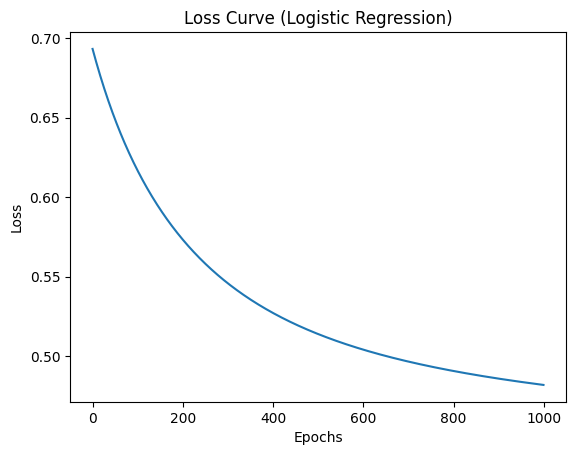

In [29]:
plt.plot(model.losses)
plt.title("Loss Curve (Logistic Regression)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [30]:
print(len(model.losses))

1000


In [31]:
print("Epochs:", model.epochs)

Epochs: 1000


In [32]:
# Here we can see that out model is imbalanced as in the confusion matrix the false-true value is 135 which is bad cuz, hte model predicts the movie to be hit even when it might be flopped. Hence, solving this issue by useing undersampling method which basically means removing few majority class's data

In [33]:
pip install imbalanced-learn

In [34]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


rus = RandomUnderSampler(random_state=42)


X_res, y_res = rus.fit_resample(X_train_scaled, y_train)

print("Before undersampling:", np.bincount(y_train))
print("After undersampling:", np.bincount(y_res))

Before undersampling: [ 634 1949]
After undersampling: [634 634]


In [35]:

model = LogisticRegression(learning_rate=0.01, epochs=1000)
model.fit(X_res, y_res)

In [36]:

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_prob(X_test_scaled)

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6377708978328174
Precision: 0.909967845659164
Recall: 0.5787321063394683
F1 Score: 0.7075
Confusion Matrix:
 [[129  28]
 [206 283]]


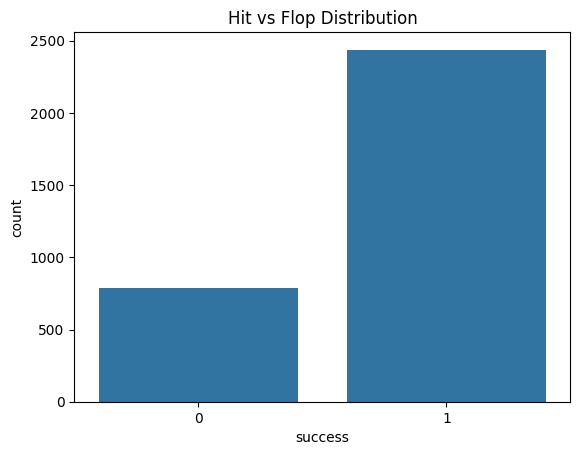

In [38]:
sns.countplot(x=y)
plt.title("Hit vs Flop Distribution")
plt.show()

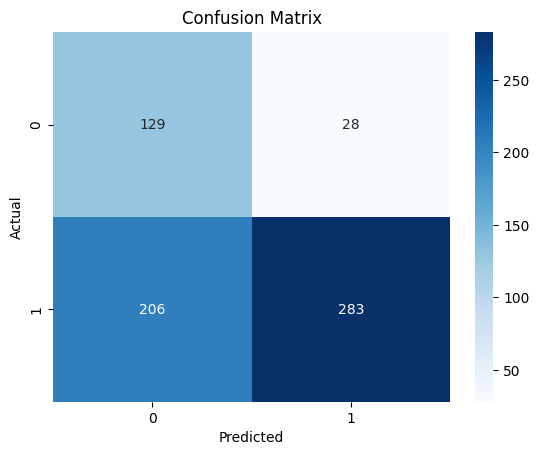

In [39]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
# Here due to undersampling we can clearly see that the model responds not good.. The false positive is improved but rest are fucked up hence we need to pick out those data from the majority class that hides alot of patterns

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

class LogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))


    def compute_class_weights(self, y):
        total = len(y)
        count_0 = np.sum(y == 0)
        count_1 = np.sum(y == 1)

        weight_0 = total / (2 * count_0)
        weight_1 = total / (2 * count_1)

        return {0: weight_0, 1: weight_1}


    def compute_loss(self, y, y_pred):
        m = len(y)

        w0 = self.class_weights[0]
        w1 = self.class_weights[1]

        loss = -(1/m) * np.sum(
            w1 * y * np.log(y_pred + 1e-15) +
            w0 * (1 - y) * np.log(1 - y_pred + 1e-15)
        )
        return loss

    def fit(self, X, y):
        self.theta = np.zeros(X.shape[1])
        self.bias = 0


        self.class_weights = self.compute_class_weights(y)

        for epoch in range(self.epochs):
            linear_model = np.dot(X, self.theta) + self.bias
            y_pred = self.sigmoid(linear_model)

            m = len(y)


            errors = y_pred - y
            weighted_errors = np.where(
                y == 1,
                self.class_weights[1] * errors,
                self.class_weights[0] * errors
            )


            dtheta = (1/m) * np.dot(X.T, weighted_errors)
            dbias = (1/m) * np.sum(weighted_errors)


            self.theta -= self.learning_rate * dtheta
            self.bias -= self.learning_rate * dbias


            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)


            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss}")

    def predict_prob(self, X):
        linear_model = np.dot(X, self.theta) + self.bias
        return self.sigmoid(linear_model)

    def predict(self, X, threshold=0.37):
        y_prob = self.predict_prob(X)
        return np.where(y_prob >= threshold, 1, 0)

In [42]:
model = LogisticRegression(learning_rate=0.01, epochs=1000)

In [43]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Epoch 0, Loss: 0.6931471805599432
Epoch 100, Loss: 0.6438120641460662
Epoch 200, Loss: 0.619621864327798
Epoch 300, Loss: 0.6050375371028447
Epoch 400, Loss: 0.595005978194428
Epoch 500, Loss: 0.5874923049673848
Epoch 600, Loss: 0.5815406750677272
Epoch 700, Loss: 0.5766445508132977
Epoch 800, Loss: 0.5725079067701775
Epoch 900, Loss: 0.5689435472192756


In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7724458204334366
Precision: 0.8313953488372093
Recall: 0.8773006134969326
F1 Score: 0.8537313432835821
Confusion Matrix:
 [[ 70  87]
 [ 60 429]]


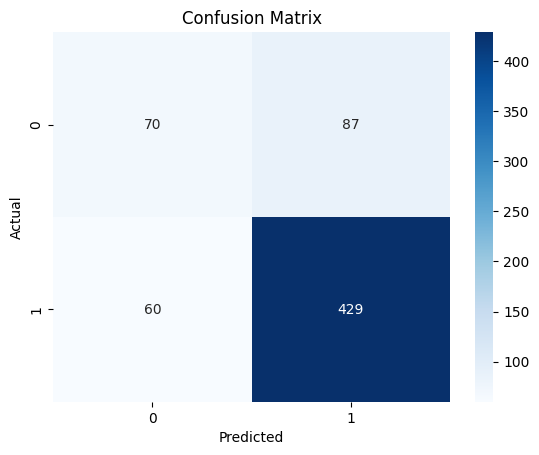

In [45]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
# So, here is the thing

In [47]:
# After optimizing our model with the help of Batch gradient descendent and using weighted loss function which is basically imbalance optimization. cht gpt it for more knowledge

In [48]:
# But yet our model's output was exactly same : the results were same as earlier confusion matrix so.. we played with the threshold.

In [49]:
# Apparantly many true 1's were lying between the probability 0.3 to 0.4 and our initial threshold was 0.5 so we decreased the threshold value until we found a point where everything was just balanced and good enough

In [50]:
# which was threshold : 0.37

In [51]:
# Now implementing the same dataset via decision tree

In [52]:
import numpy as np

class DecisionTree:
    class Node:
        def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
            self.feature = feature
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value

    def __init__(self, max_depth=5):
        self.max_depth = max_depth
        self.root = None

    # Gini impurity
    def gini(self, y):
        m = len(y)
        if m == 0:
            return 0

        p1 = np.sum(y == 1) / m
        p0 = np.sum(y == 0) / m

        return 1 - (p1**2 + p0**2)

    # Find best split
    def best_split(self, X, y):
        best_feature = None
        best_threshold = None
        best_gini = float('inf')

        n_samples, n_features = X.shape

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])

            for t in thresholds:
                left_idx = X[:, feature] <= t
                right_idx = X[:, feature] > t

                y_left = y[left_idx]
                y_right = y[right_idx]

                g_left = self.gini(y_left)
                g_right = self.gini(y_right)

                w_gini = (len(y_left)/n_samples)*g_left + (len(y_right)/n_samples)*g_right

                if w_gini < best_gini:
                    best_gini = w_gini
                    best_feature = feature
                    best_threshold = t

        return best_feature, best_threshold

    # Most common label
    def most_common_label(self, y):
        return np.bincount(y).argmax()

    # Build tree recursively
    def build_tree(self, X, y, depth=0):
        num_samples = len(y)
        num_labels = len(np.unique(y))

        # Stopping condition
        if depth >= self.max_depth or num_labels == 1:
            return self.Node(value=self.most_common_label(y))

        feature, threshold = self.best_split(X, y)

        left_idx = X[:, feature] <= threshold
        right_idx = X[:, feature] > threshold

        left = self.build_tree(X[left_idx], y[left_idx], depth + 1)
        right = self.build_tree(X[right_idx], y[right_idx], depth + 1)

        return self.Node(feature, threshold, left, right)

    # Train
    def fit(self, X, y):
        self.root = self.build_tree(X, y)

    # Traverse tree
    def traverse(self, x, node):
        if node.value is not None:
            return node.value

        if x[node.feature] <= node.threshold:
            return self.traverse(x, node.left)
        else:
            return self.traverse(x, node.right)

    # Predict
    def predict(self, X):
        return np.array([self.traverse(x, self.root) for x in X])

In [53]:
tree = DecisionTree(max_depth=5)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

In [54]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
 [[ 70  87]
 [ 53 436]]
Accuracy: 0.7832817337461301
Precision: 0.8336520076481836
Recall: 0.8916155419222904
F1 Score: 0.8616600790513834


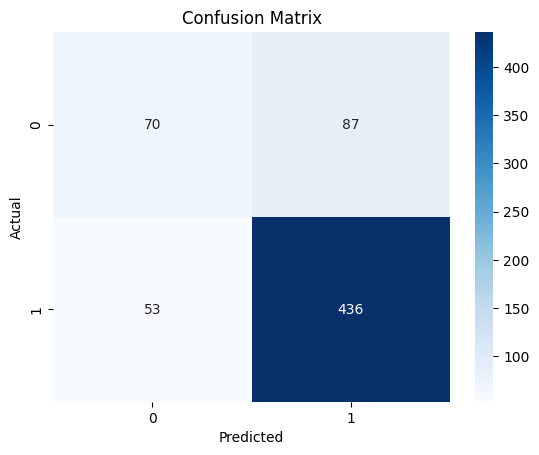

In [55]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [56]:
#Captures non-linear patterns,Doesn’t assume linear boundary (unlike logistic regression),Naturally improves recall but likely overfitting slightly so to improve that we will train the model again witht the max depth as 3 instead of 5


In [57]:
tree = DecisionTree(max_depth=3)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

In [58]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
 [[ 84  73]
 [ 69 420]]
Accuracy: 0.7801857585139319
Precision: 0.8519269776876268
Recall: 0.8588957055214724
F1 Score: 0.8553971486761711


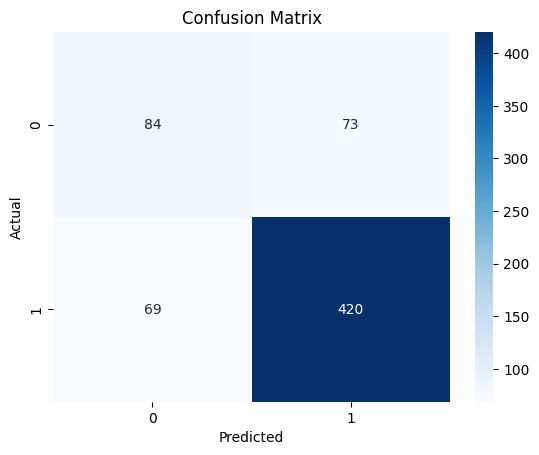

In [59]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
# Now, the current model of decision tree is the best one so far.. What we did was Hyperparameter tuning and Bias-variance balancing

In [61]:
# after training our current model with all above two models we got to know that our data is imbalanced,it has complex patterns and needs Need good recall + precision hence now, we would be using random forest model

In [62]:
import numpy as np

class RandomForest:
    class Node:
        def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
            self.feature = feature
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value

    class DecisionTree:
        def __init__(self, max_depth):
            self.max_depth = max_depth
            self.root = None

        def gini(self, y):
            m = len(y)
            if m == 0:
                return 0
            p1 = np.sum(y == 1) / m
            p0 = np.sum(y == 0) / m
            return 1 - (p1**2 + p0**2)

        def best_split(self, X, y):
            best_feature, best_threshold, best_gini = None, None, float('inf')
            n_samples, n_features = X.shape

            features = np.random.choice(n_features, int(np.sqrt(n_features)), replace=False)

            for feature in features:
                thresholds = np.unique(X[:, feature])
                for t in thresholds:
                    left_idx = X[:, feature] <= t
                    right_idx = X[:, feature] > t

                    y_left, y_right = y[left_idx], y[right_idx]

                    g = (len(y_left)/n_samples)*self.gini(y_left) + (len(y_right)/n_samples)*self.gini(y_right)

                    if g < best_gini:
                        best_feature, best_threshold, best_gini = feature, t, g

            return best_feature, best_threshold

        def most_common_label(self, y):
            return np.bincount(y).argmax()

        def build(self, X, y, depth):
            if depth >= self.max_depth or len(np.unique(y)) == 1:
                return RandomForest.Node(value=self.most_common_label(y))

            feature, threshold = self.best_split(X, y)

            left_idx = X[:, feature] <= threshold
            right_idx = X[:, feature] > threshold

            left = self.build(X[left_idx], y[left_idx], depth + 1)
            right = self.build(X[right_idx], y[right_idx], depth + 1)

            return RandomForest.Node(feature, threshold, left, right)

        def fit(self, X, y):
            self.root = self.build(X, y, 0)

        def traverse(self, x, node):
            if node.value is not None:
                return node.value

            if x[node.feature] <= node.threshold:
                return self.traverse(x, node.left)
            else:
                return self.traverse(x, node.right)

        def predict(self, X):
            return np.array([self.traverse(x, self.root) for x in X])


    def __init__(self, n_trees=5, max_depth=5):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.trees = []

    # Bootstrap sampling
    def bootstrap(self, X, y):
        n_samples = X.shape[0]
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]

    def fit(self, X, y):
        self.trees = []

        for _ in range(self.n_trees):
            tree = self.DecisionTree(max_depth=self.max_depth)
            X_sample, y_sample = self.bootstrap(X, y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])

        # Majority voting
        final_preds = []
        for i in range(X.shape[0]):
            counts = np.bincount(tree_preds[:, i])
            final_preds.append(np.argmax(counts))

        return np.array(final_preds)

In [63]:
X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

In [64]:
rf = RandomForest(n_trees=5, max_depth=5)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [65]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
 [[ 59  98]
 [ 33 456]]
Accuracy: 0.7972136222910217
Precision: 0.8231046931407943
Recall: 0.9325153374233128
F1 Score: 0.8744007670182167


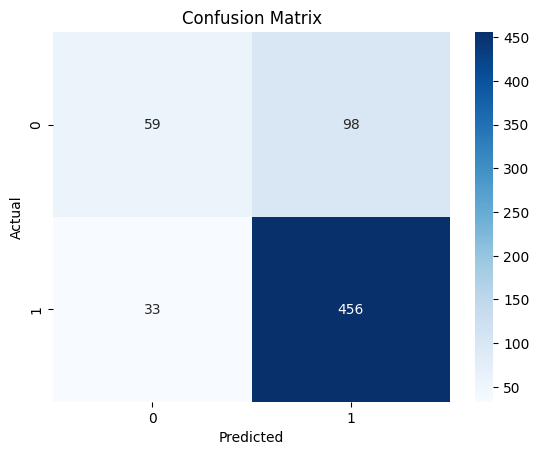

In [66]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [67]:
# Our current model is perfect than any of the before models but it is a bit more aggresive towards 1s which can be solved

In [100]:
rf = RandomForest(n_trees=5, max_depth=4)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [101]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
 [[ 29 128]
 [ 12 477]]
Accuracy: 0.7832817337461301
Precision: 0.7884297520661157
Recall: 0.9754601226993865
F1 Score: 0.8720292504570384


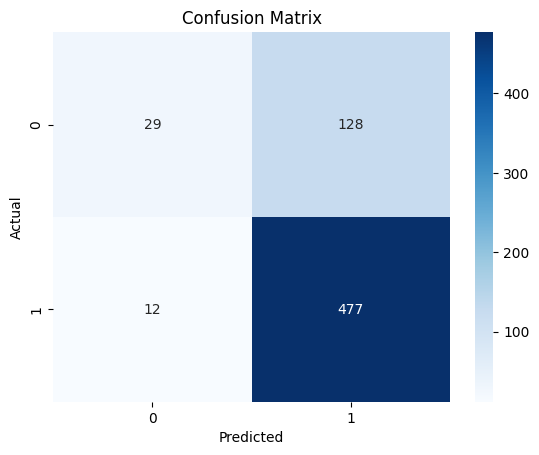

In [102]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [103]:
# You want balanced model
# You care about precision + recall equally
# You want fewer false alarms

In [104]:
# Above are the points that our model satisfies

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [106]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns # Import seaborn for heatmap to get the cmap functionality

def plot_all_cm(y_test, y_preds, titles, cmap='Greys'): # Changed default cmap to 'Greys'
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for i, (y_pred, title) in enumerate(zip(y_preds, titles)):
        cm = confusion_matrix(y_test, y_pred)

        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i], cbar=False) # Used sns.heatmap with cmap and ax
        axes[i].set_title(title)
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

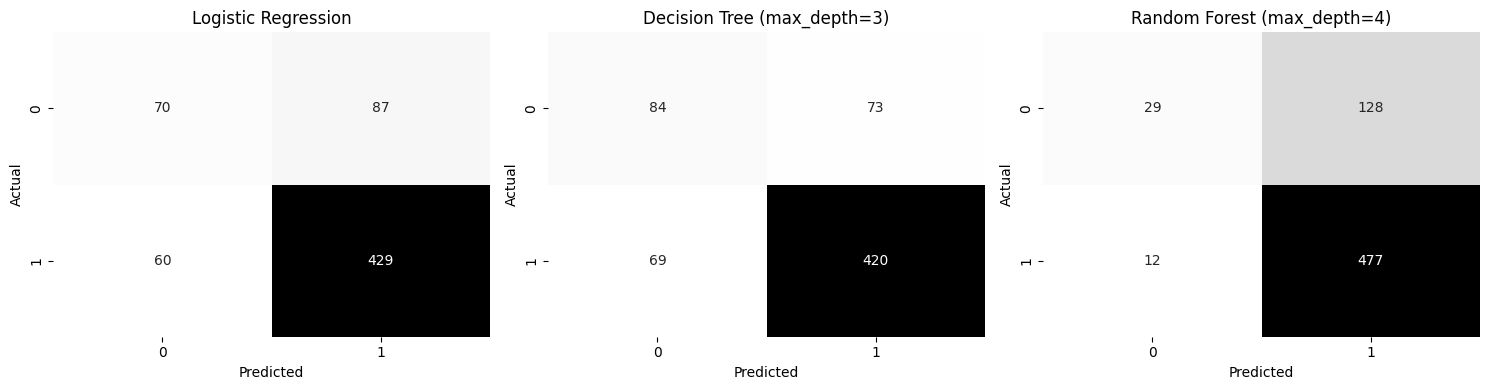

In [107]:
y_pred_lr = model.predict(X_test) # from the weighted Logistic Regression model
y_pred_dt = tree.predict(X_test) # from the Decision Tree model (max_depth=3)
y_pred_rf = rf.predict(X_test) # from the Random Forest model (max_depth=4)

y_preds_all_models = [y_pred_lr, y_pred_dt, y_pred_rf]
titles_all_models = ['Logistic Regression', 'Decision Tree (max_depth=3)', 'Random Forest (max_depth=4)']

plot_all_cm(y_test, y_preds_all_models, titles_all_models, cmap='Greys') # Passed the new colormap